In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [1]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns
from scipy.stats import spearmanr
import time_normalization_helpers

# 1. Filtering data to tiles appropriate for fit

In [2]:
activities = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities_bootstrapped_error_active_pval.csv", index_col = 0)
#dbd_norm_activities = dbd_norm_activities[["ADseq",  "AD_end", "AD_BC", "RPTR_BC", "time", "rep", "shifted_activity"]]
activities = activities.rename(columns = {"mean" : "activity"})
activities["error"] = (activities["ci_hi"] - activities["ci_low"]) / (2 * 1.96)
activities

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error
0,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0.366271,-0.011219,0.707915,ns,NaN,NaN,0.183453
1,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,5,0.469570,0.204091,0.840484,ns,NaN,NaN,0.162345
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,10,0.126289,-0.162042,0.268215,ns,NaN,NaN,0.109759
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,15,0.189880,-0.123463,0.409278,ns,NaN,NaN,0.135903
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,20,0.063215,-0.080826,0.187016,ns,NaN,NaN,0.068327
...,...,...,...,...,...,...,...,...,...
118808,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,20,0.509707,0.421654,0.581735,ns,0.517976,0.013440,0.040837
118809,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,30,0.647316,0.497563,0.797139,ns,0.655585,0.000621,0.076422
118810,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,40,0.752322,0.607649,0.938344,ns,0.760591,0.000550,0.084361
118811,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,50,0.674640,0.585810,0.770303,ns,0.682909,0.000548,0.047065


In [3]:
activities["ADseq"].value_counts()

ADseq
AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD    10
AAAANNAAGPASYLSQLPQVQRYYPNNMNALSSLLDPSSA    10
AAAASTSKSAEKEKPVTKKELKRREKQALLEKKKKLLEIA    10
AAAKLATSGVDNITPTPAFQRRSYDISMNSSFKILPTSQA    10
AAATTTSAPHNLSIVSPNPTYSPNPLSLYLTNSKNPLNSG    10
                                            ..
YRKVTKKFGSKSSNLLLRYRRSIDLANDRRIPDFITIPNR     1
YSAMLTTCIRKYSTAKGMSLSEIYAGIRELFPYYKYCPDG     1
YSDIDVDGLCSELMAKAKCSERGVVINAEDVQLALNKHMN     1
YVDSSLDVVSFQNDVWAKASLLQHISNTHFLCGMMQFMRD     1
YVSIESIHKSLKSFWLNFHPQYGLLHKPSFHVDKQPAILN     1
Name: count, Length: 13463, dtype: int64

In [4]:
# get last timepoint per ADseq
last = (
    activities.sort_values("time")
      .groupby("ADseq")
      .tail(1)
)

# find ADseqs where the last time point is active
keep_adseq = (
    last.groupby("ADseq")["class"]
    .apply(lambda x: (x == "activator").any())
)

# filter original df
active_tile_activities = activities[activities["ADseq"].isin(keep_adseq[keep_adseq].index)]
active_tile_activities

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error
142,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.402631,-0.569555,-0.165864,ns,NaN,NaN,0.102982
143,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2,0.067719,-0.086268,0.196101,ns,0.470349,0.009113,0.072033
144,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.423909,0.019486,0.796737,activator,0.826539,0.001168,0.198278
145,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786642,0.691610,0.871152,activator,1.189273,0.000881,0.045801
146,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.567249,0.388742,0.736468,activator,0.969880,0.000730,0.088706
...,...,...,...,...,...,...,...,...,...
118600,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,20,1.560700,1.399946,1.635293,activator,1.430020,0.000730,0.060037
118601,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,30,1.707046,1.668821,1.736109,activator,1.576366,0.000621,0.017165
118602,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,40,1.721909,1.702173,1.740391,activator,1.591228,0.000550,0.009749
118603,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,50,1.650853,1.592250,1.699947,activator,1.520173,0.000548,0.027474


In [5]:
active_tile_activities["ADseq"].value_counts()

ADseq
AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY    10
AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS    10
AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS    10
AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF    10
AFGSFVTEDQEKMEVSFNIFNEITIQDLNFLQFSSIPKLW    10
                                            ..
SNSNSTGNLNSSYFNSLNIDSMLDDYVSSDLLLNDDDDDT     8
WELQMFKTENVPESTTLPAVDNNNLFDAVASPLADPLCDD     8
YTKGGALFLDNKNLLLDTIKDIENDRLLDLPGIASWHTLK     8
LNLPLVTPIISCDCGLTKEIEAFNNIFLPLSNPPLTSKKN     7
SINGSEMPDFSLDLVSNDRQTGLEALDYDIHNYFPQHSER     5
Name: count, Length: 869, dtype: int64

In [6]:
expected = np.array([0, 2, 5, 10, 15, 20, 30, 40, 50, 60])

def ok(grp):
    t = set(grp["time"].unique())

    missing = [x for x in expected if x not in t]

    if len(missing) > 3: # Want at least 7 time points
        return False

    if len(missing) <= 1:
        return True

    # check if missing are isolated in the expected sequence
    idx = np.where(np.isin(expected, missing))[0]

    # if indices are consecutive → bad
    if len(idx) > 1 and np.any(np.diff(idx) == 1):
        return False

    return True

active_tile_activities_count_filtered = active_tile_activities.groupby("ADseq").filter(ok)
active_tile_activities_count_filtered

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error
142,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.402631,-0.569555,-0.165864,ns,NaN,NaN,0.102982
143,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2,0.067719,-0.086268,0.196101,ns,0.470349,0.009113,0.072033
144,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.423909,0.019486,0.796737,activator,0.826539,0.001168,0.198278
145,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786642,0.691610,0.871152,activator,1.189273,0.000881,0.045801
146,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.567249,0.388742,0.736468,activator,0.969880,0.000730,0.088706
...,...,...,...,...,...,...,...,...,...
118600,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,20,1.560700,1.399946,1.635293,activator,1.430020,0.000730,0.060037
118601,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,30,1.707046,1.668821,1.736109,activator,1.576366,0.000621,0.017165
118602,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,40,1.721909,1.702173,1.740391,activator,1.591228,0.000550,0.009749
118603,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,50,1.650853,1.592250,1.699947,activator,1.520173,0.000548,0.027474


In [7]:
active_tile_activities_count_filtered["ADseq"].value_counts()

ADseq
AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY    10
AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS    10
AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS    10
AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF    10
AFGSFVTEDQEKMEVSFNIFNEITIQDLNFLQFSSIPKLW    10
                                            ..
TQKAVVFTDDRNNIDLQLQLLTNFLNLNGDFNHLPNFLLL     9
TTSSTIAYGQISDVDLIDTYYEFIHVGFPIIPLNKTTLTS     9
WLSDENDGASHINVNKDSSSVLSASSSTWFEPLENIISSA     9
WYLSGLAFRIAHEIGLHLNPEAWSNVYEDELSIMDFEVRS     9
AETFSSFRPDMNMTMNMNLHNASTSSFNNEAFWKPLDSAI     8
Name: count, Length: 857, dtype: int64

In [8]:
# --- further filter to ensure time=0 exists ---
active_tile_activities_count_filtered = active_tile_activities_count_filtered.groupby('ADseq').filter(lambda x: 0 in x['time'].values)
active_tile_activities_count_filtered

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error
142,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.402631,-0.569555,-0.165864,ns,NaN,NaN,0.102982
143,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2,0.067719,-0.086268,0.196101,ns,0.470349,0.009113,0.072033
144,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.423909,0.019486,0.796737,activator,0.826539,0.001168,0.198278
145,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786642,0.691610,0.871152,activator,1.189273,0.000881,0.045801
146,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.567249,0.388742,0.736468,activator,0.969880,0.000730,0.088706
...,...,...,...,...,...,...,...,...,...
118600,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,20,1.560700,1.399946,1.635293,activator,1.430020,0.000730,0.060037
118601,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,30,1.707046,1.668821,1.736109,activator,1.576366,0.000621,0.017165
118602,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,40,1.721909,1.702173,1.740391,activator,1.591228,0.000550,0.009749
118603,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,50,1.650853,1.592250,1.699947,activator,1.520173,0.000548,0.027474


In [9]:
active_tile_activities_count_filtered["ADseq"].value_counts()

ADseq
AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY    10
AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS    10
AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS    10
AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF    10
AFGSFVTEDQEKMEVSFNIFNEITIQDLNFLQFSSIPKLW    10
                                            ..
TQKAVVFTDDRNNIDLQLQLLTNFLNLNGDFNHLPNFLLL     9
TTSSTIAYGQISDVDLIDTYYEFIHVGFPIIPLNKTTLTS     9
WLSDENDGASHINVNKDSSSVLSASSSTWFEPLENIISSA     9
WYLSGLAFRIAHEIGLHLNPEAWSNVYEDELSIMDFEVRS     9
AETFSSFRPDMNMTMNMNLHNASTSSFNNEAFWKPLDSAI     8
Name: count, Length: 857, dtype: int64

In [10]:
activities_norm = active_tile_activities_count_filtered.copy()

# map time=0 activity per ADseq directly
baseline = activities_norm[activities_norm["time"] == 0].set_index("ADseq")["activity"]
activities_norm["activity_norm"] = (activities_norm["activity"] - activities_norm["ADseq"].map(baseline)).clip(lower=0)

#activities_norm = activities_norm.drop(columns = ["activity_0"])
activities_norm

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,activity_norm
142,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.402631,-0.569555,-0.165864,ns,NaN,NaN,0.102982,0.000000
143,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2,0.067719,-0.086268,0.196101,ns,0.470349,0.009113,0.072033,0.470349
144,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.423909,0.019486,0.796737,activator,0.826539,0.001168,0.198278,0.826539
145,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786642,0.691610,0.871152,activator,1.189273,0.000881,0.045801,1.189273
146,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.567249,0.388742,0.736468,activator,0.969880,0.000730,0.088706,0.969880
...,...,...,...,...,...,...,...,...,...,...
118600,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,20,1.560700,1.399946,1.635293,activator,1.430020,0.000730,0.060037,1.430020
118601,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,30,1.707046,1.668821,1.736109,activator,1.576366,0.000621,0.017165,1.576366
118602,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,40,1.721909,1.702173,1.740391,activator,1.591228,0.000550,0.009749,1.591228
118603,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,50,1.650853,1.592250,1.699947,activator,1.520173,0.000548,0.027474,1.520173


In [11]:
activities_norm["ci_low_norm"] = activities_norm["ci_low"] - activities_norm["activity"] + activities_norm["activity_norm"]
activities_norm["ci_hi_norm"] = activities_norm["ci_hi"] - activities_norm["activity"] + activities_norm["activity_norm"]
activities_norm

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,activity_norm,ci_low_norm,ci_hi_norm
142,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.402631,-0.569555,-0.165864,ns,NaN,NaN,0.102982,0.000000,-0.166925,0.236767
143,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2,0.067719,-0.086268,0.196101,ns,0.470349,0.009113,0.072033,0.470349,0.316362,0.598732
144,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.423909,0.019486,0.796737,activator,0.826539,0.001168,0.198278,0.826539,0.422117,1.199367
145,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786642,0.691610,0.871152,activator,1.189273,0.000881,0.045801,1.189273,1.094241,1.273783
146,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.567249,0.388742,0.736468,activator,0.969880,0.000730,0.088706,0.969880,0.791373,1.139099
...,...,...,...,...,...,...,...,...,...,...,...,...
118600,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,20,1.560700,1.399946,1.635293,activator,1.430020,0.000730,0.060037,1.430020,1.269266,1.504612
118601,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,30,1.707046,1.668821,1.736109,activator,1.576366,0.000621,0.017165,1.576366,1.538140,1.605428
118602,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,40,1.721909,1.702173,1.740391,activator,1.591228,0.000550,0.009749,1.591228,1.571493,1.609710
118603,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,50,1.650853,1.592250,1.699947,activator,1.520173,0.000548,0.027474,1.520173,1.461570,1.569266


In [12]:
activities_norm.to_csv("../../../output/ChopTFs_pipeline/speed/activities_to_fit.csv")

# Baseline activity over time

100%|██████████| 9/9 [00:00<00:00, 46.62it/s]


(<Figure size 2400x3600 with 9 Axes>,
 array([<Axes: ylabel='2 min.'>, <Axes: ylabel='5 min.'>,
        <Axes: ylabel='10 min.'>, <Axes: ylabel='15 min.'>,
        <Axes: ylabel='20 min.'>, <Axes: ylabel='30 min.'>,
        <Axes: ylabel='40 min.'>, <Axes: ylabel='50 min.'>,
        <Axes: ylabel='60 min.'>], dtype=object))

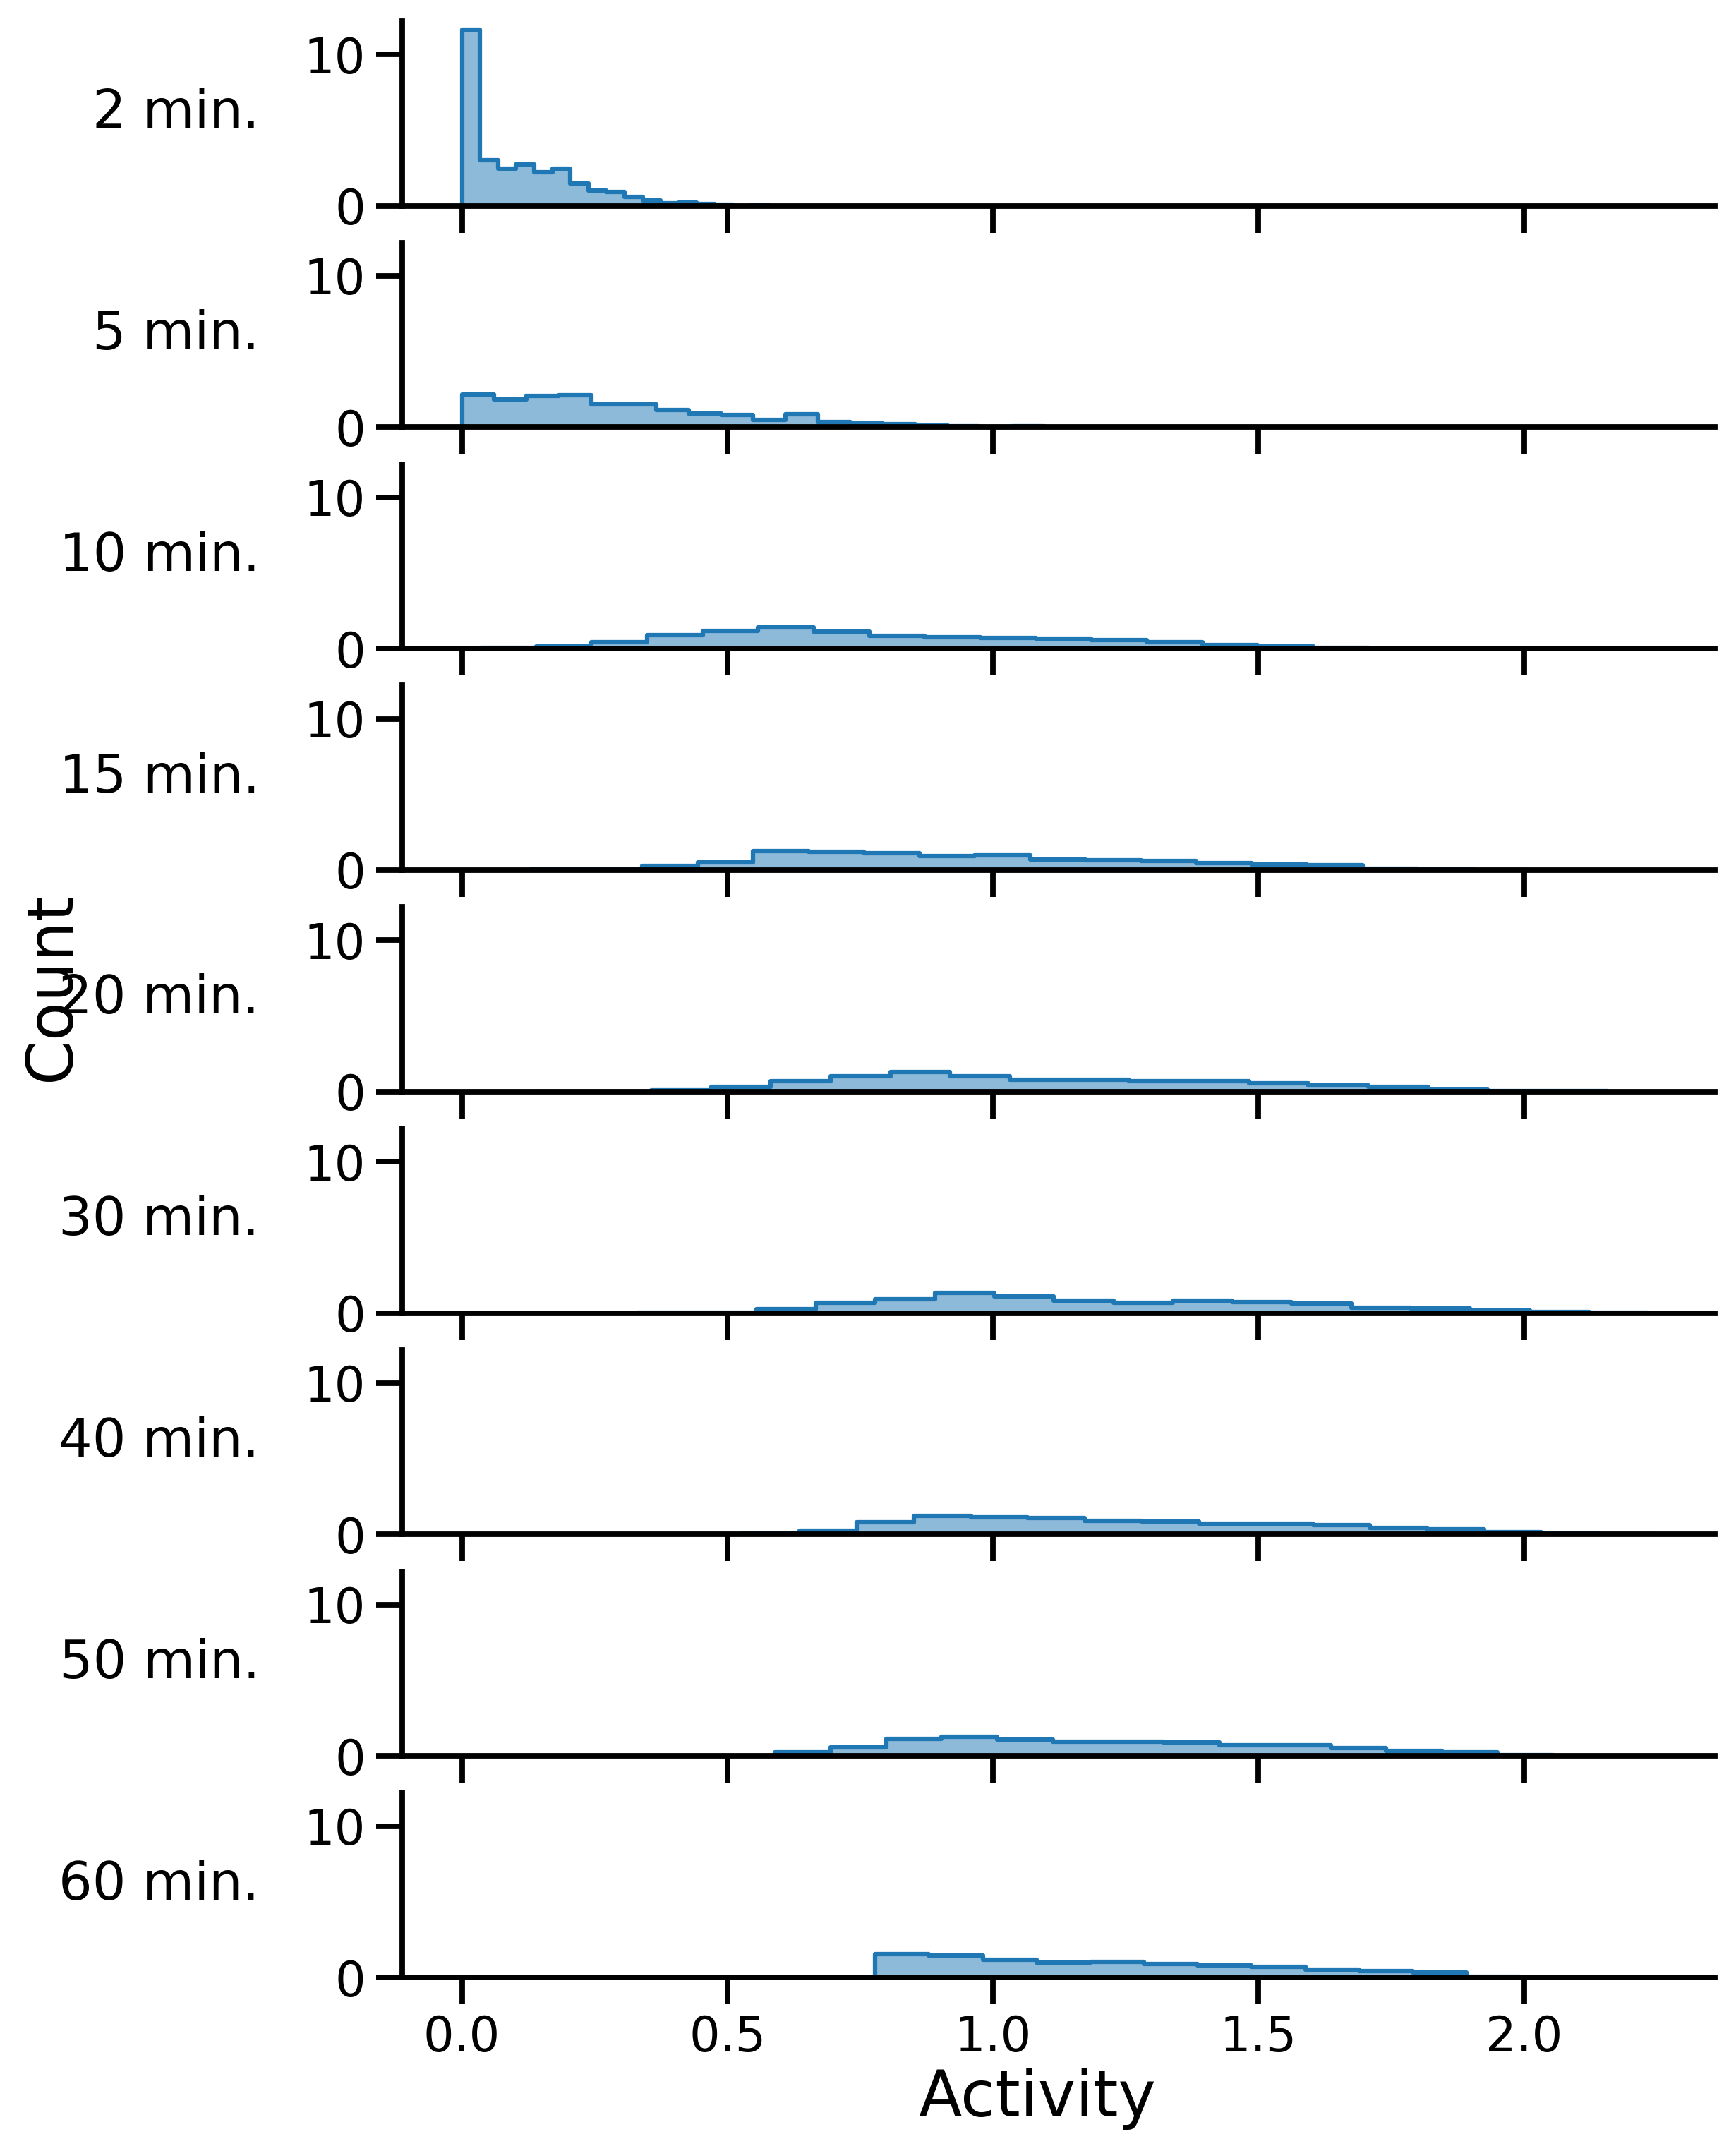

In [13]:
time_normalization_helpers.plot_hists_over_time(activities_norm[activities_norm["time"] != 0], column = "activity_norm")

# 2. plotting raw vs baseline activities

In [14]:
max_activities = activities_norm.groupby("ADseq")[["activity", "activity_norm"]].max().reset_index()
max_activities = pd.merge(max_activities, activities_norm[activities_norm["time"] == 0][["ADseq", "activity"]].rename(columns = {"activity" : "activity_t0"}))
max_activities

,ADseq,activity,activity_norm,activity_t0
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0.801983,1.204614,-0.402631
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,1.970491,1.550627,0.419864
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,1.285137,1.411124,-0.125987
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,1.191691,1.014475,0.177217
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,1.624554,1.486441,0.138114
...,...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,1.376673,1.453678,-0.077005
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,1.136863,0.996907,0.139956
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,1.463755,1.520583,-0.056828
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,1.288224,1.192689,0.095535


Pearson r = 0.251
Spearman r = 0.275, p = 2.38e-16


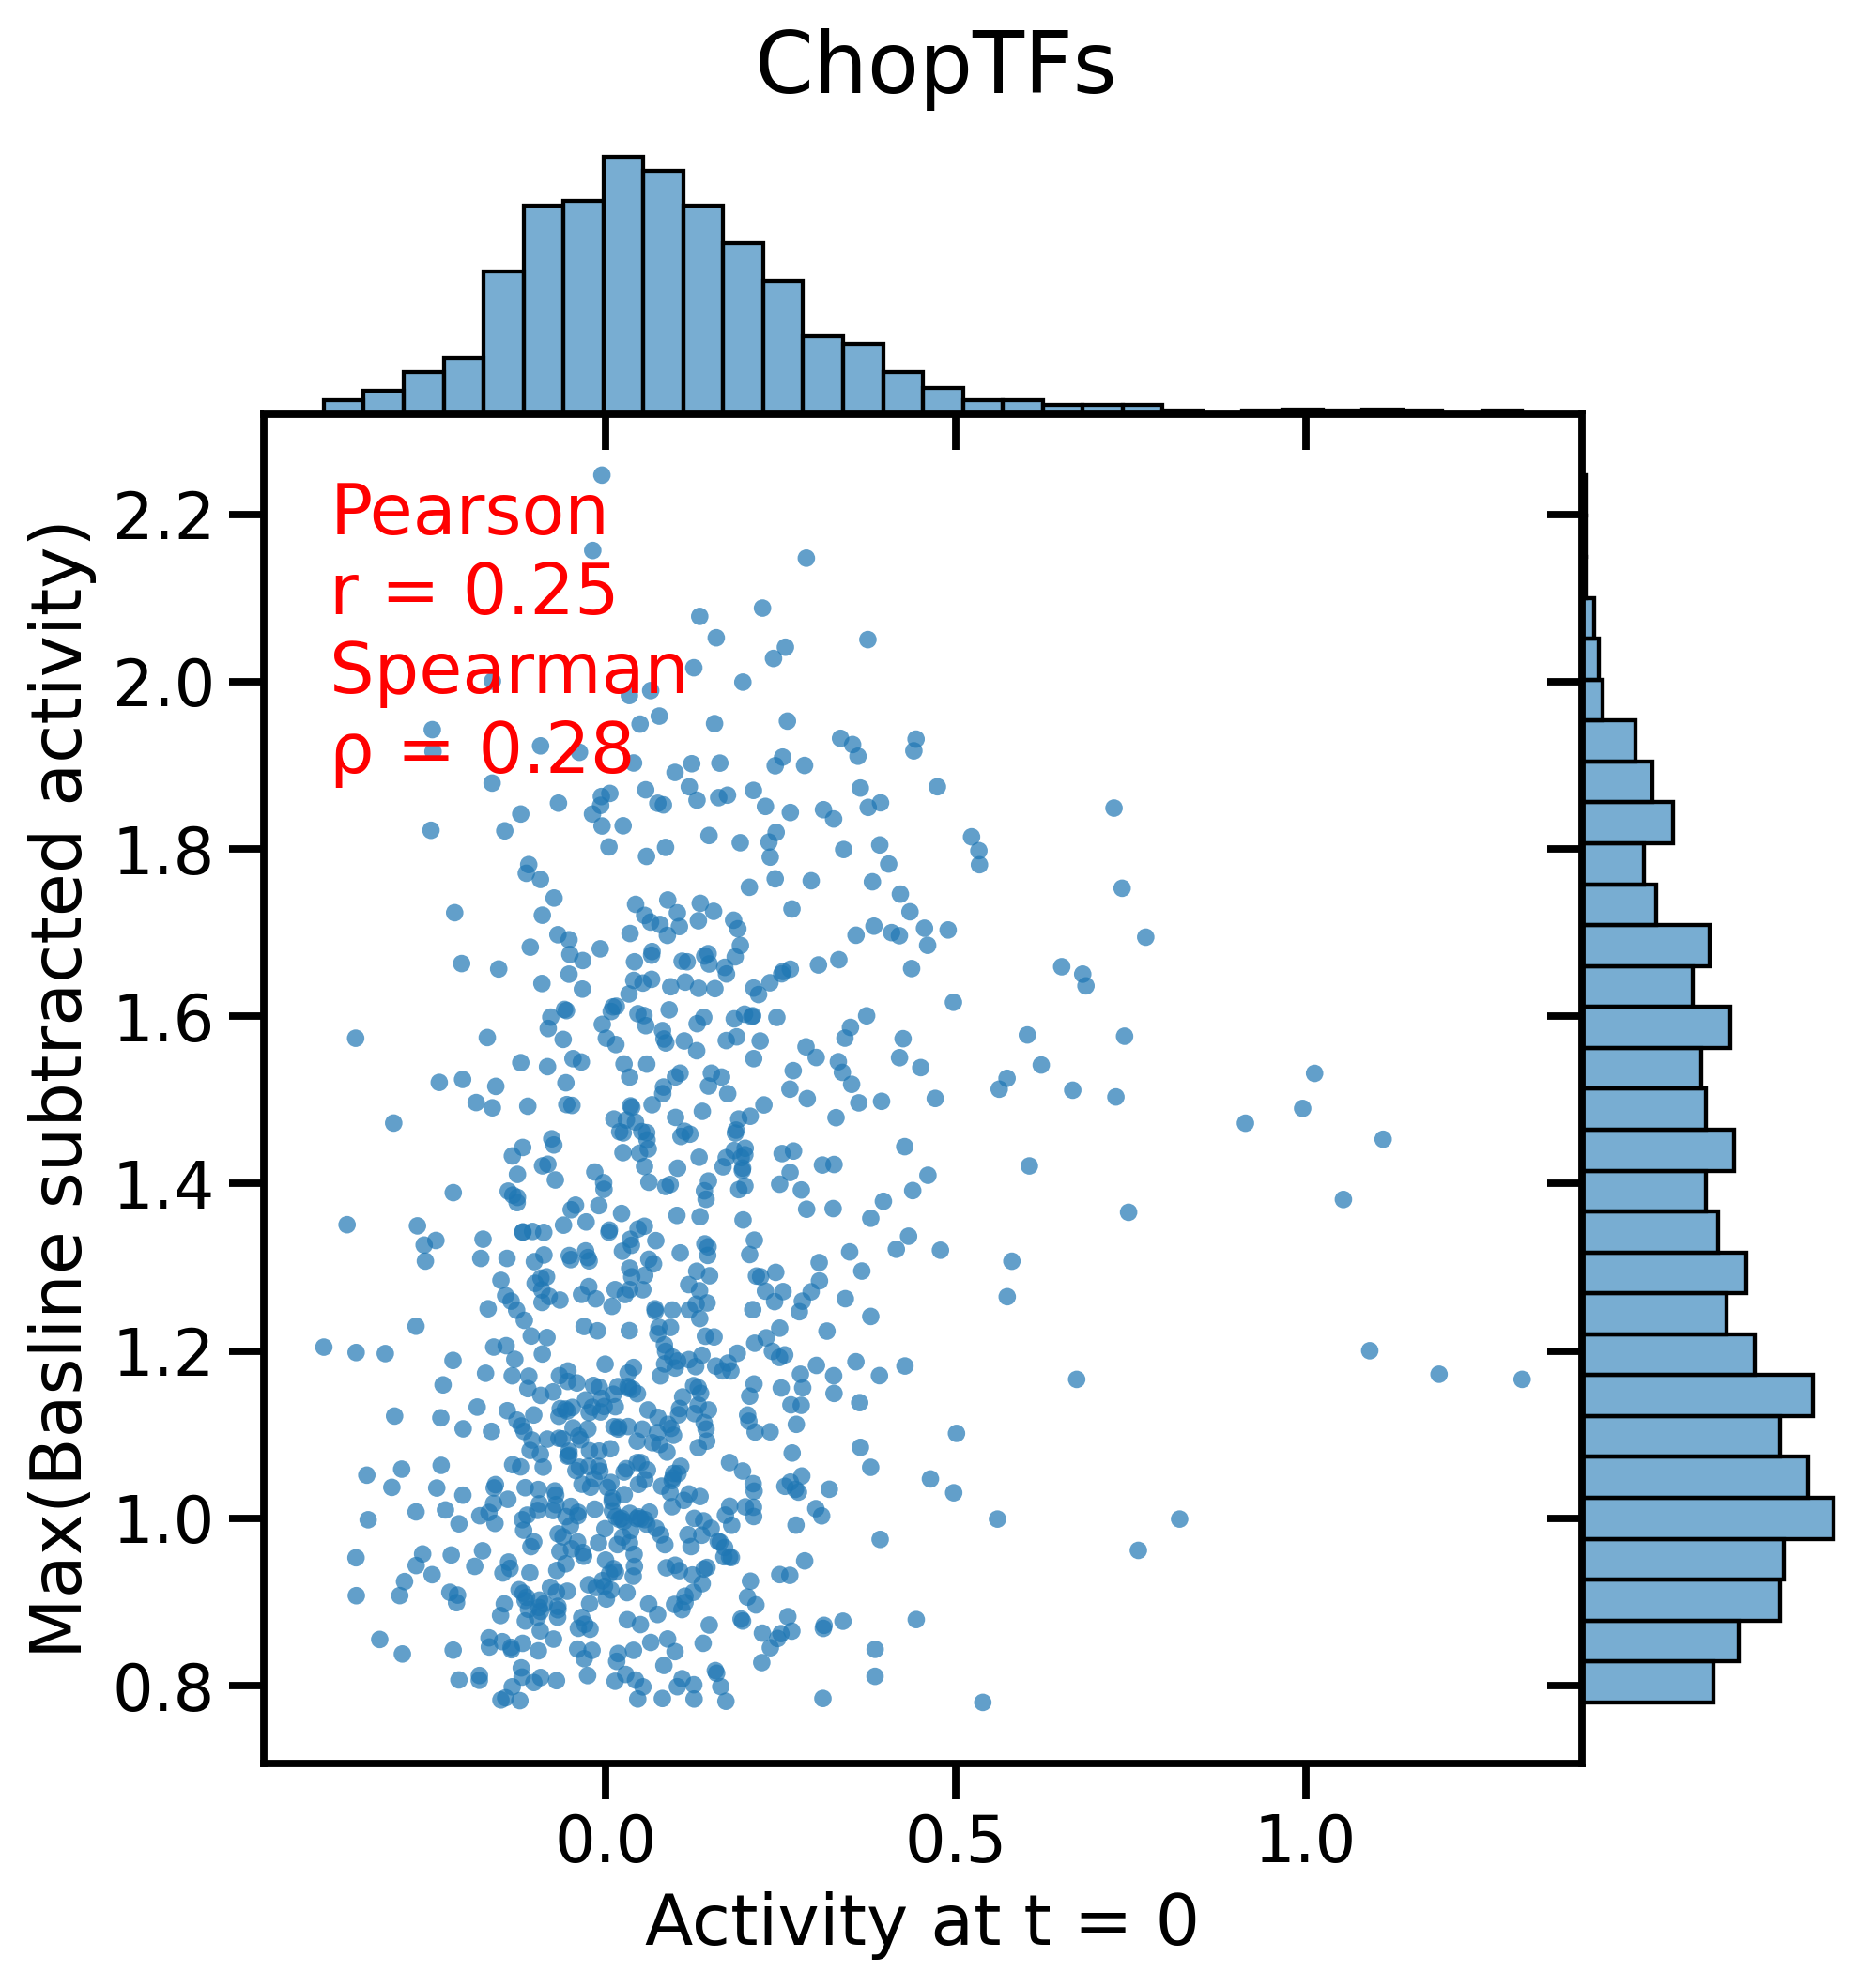

In [15]:
## Plotting
x = max_activities["activity_t0"]
y = max_activities["activity_norm"]

# correlations
pearson_r = np.corrcoef(x, y)[0, 1]
spearman_r, spearman_p = spearmanr(x, y)

print(f"Pearson r = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.2e}")

sns.set_context('talk')

# joint plot with marginal histograms
g = sns.JointGrid(data=max_activities, x="activity_t0", y="activity_norm", height=7, space=0)

# main scatter
g.plot_joint(
    sns.scatterplot,
    alpha=0.7,
    edgecolor='none',
    s=20
)

# marginal histograms
g.plot_marginals(
    sns.histplot,
    bins=30,
    alpha=0.6
)

# labels
g.set_axis_labels("Activity at t = 0", "Max(Basline subtracted activity)")

# annotation
g.ax_joint.text(
    0.05, 0.95,
    f"Pearson\nr = {pearson_r:.2f}\nSpearman\nρ = {spearman_r:.2f}",
    transform=g.ax_joint.transAxes,
    ha='left',
    va='top',
    color = 'red'
)

g.fig.set_dpi(300)
g.fig.suptitle("ChopTFs", y=1.02)

plt.show()

Pearson r = 0.694
Spearman r = 0.662, p = 3.53e-109


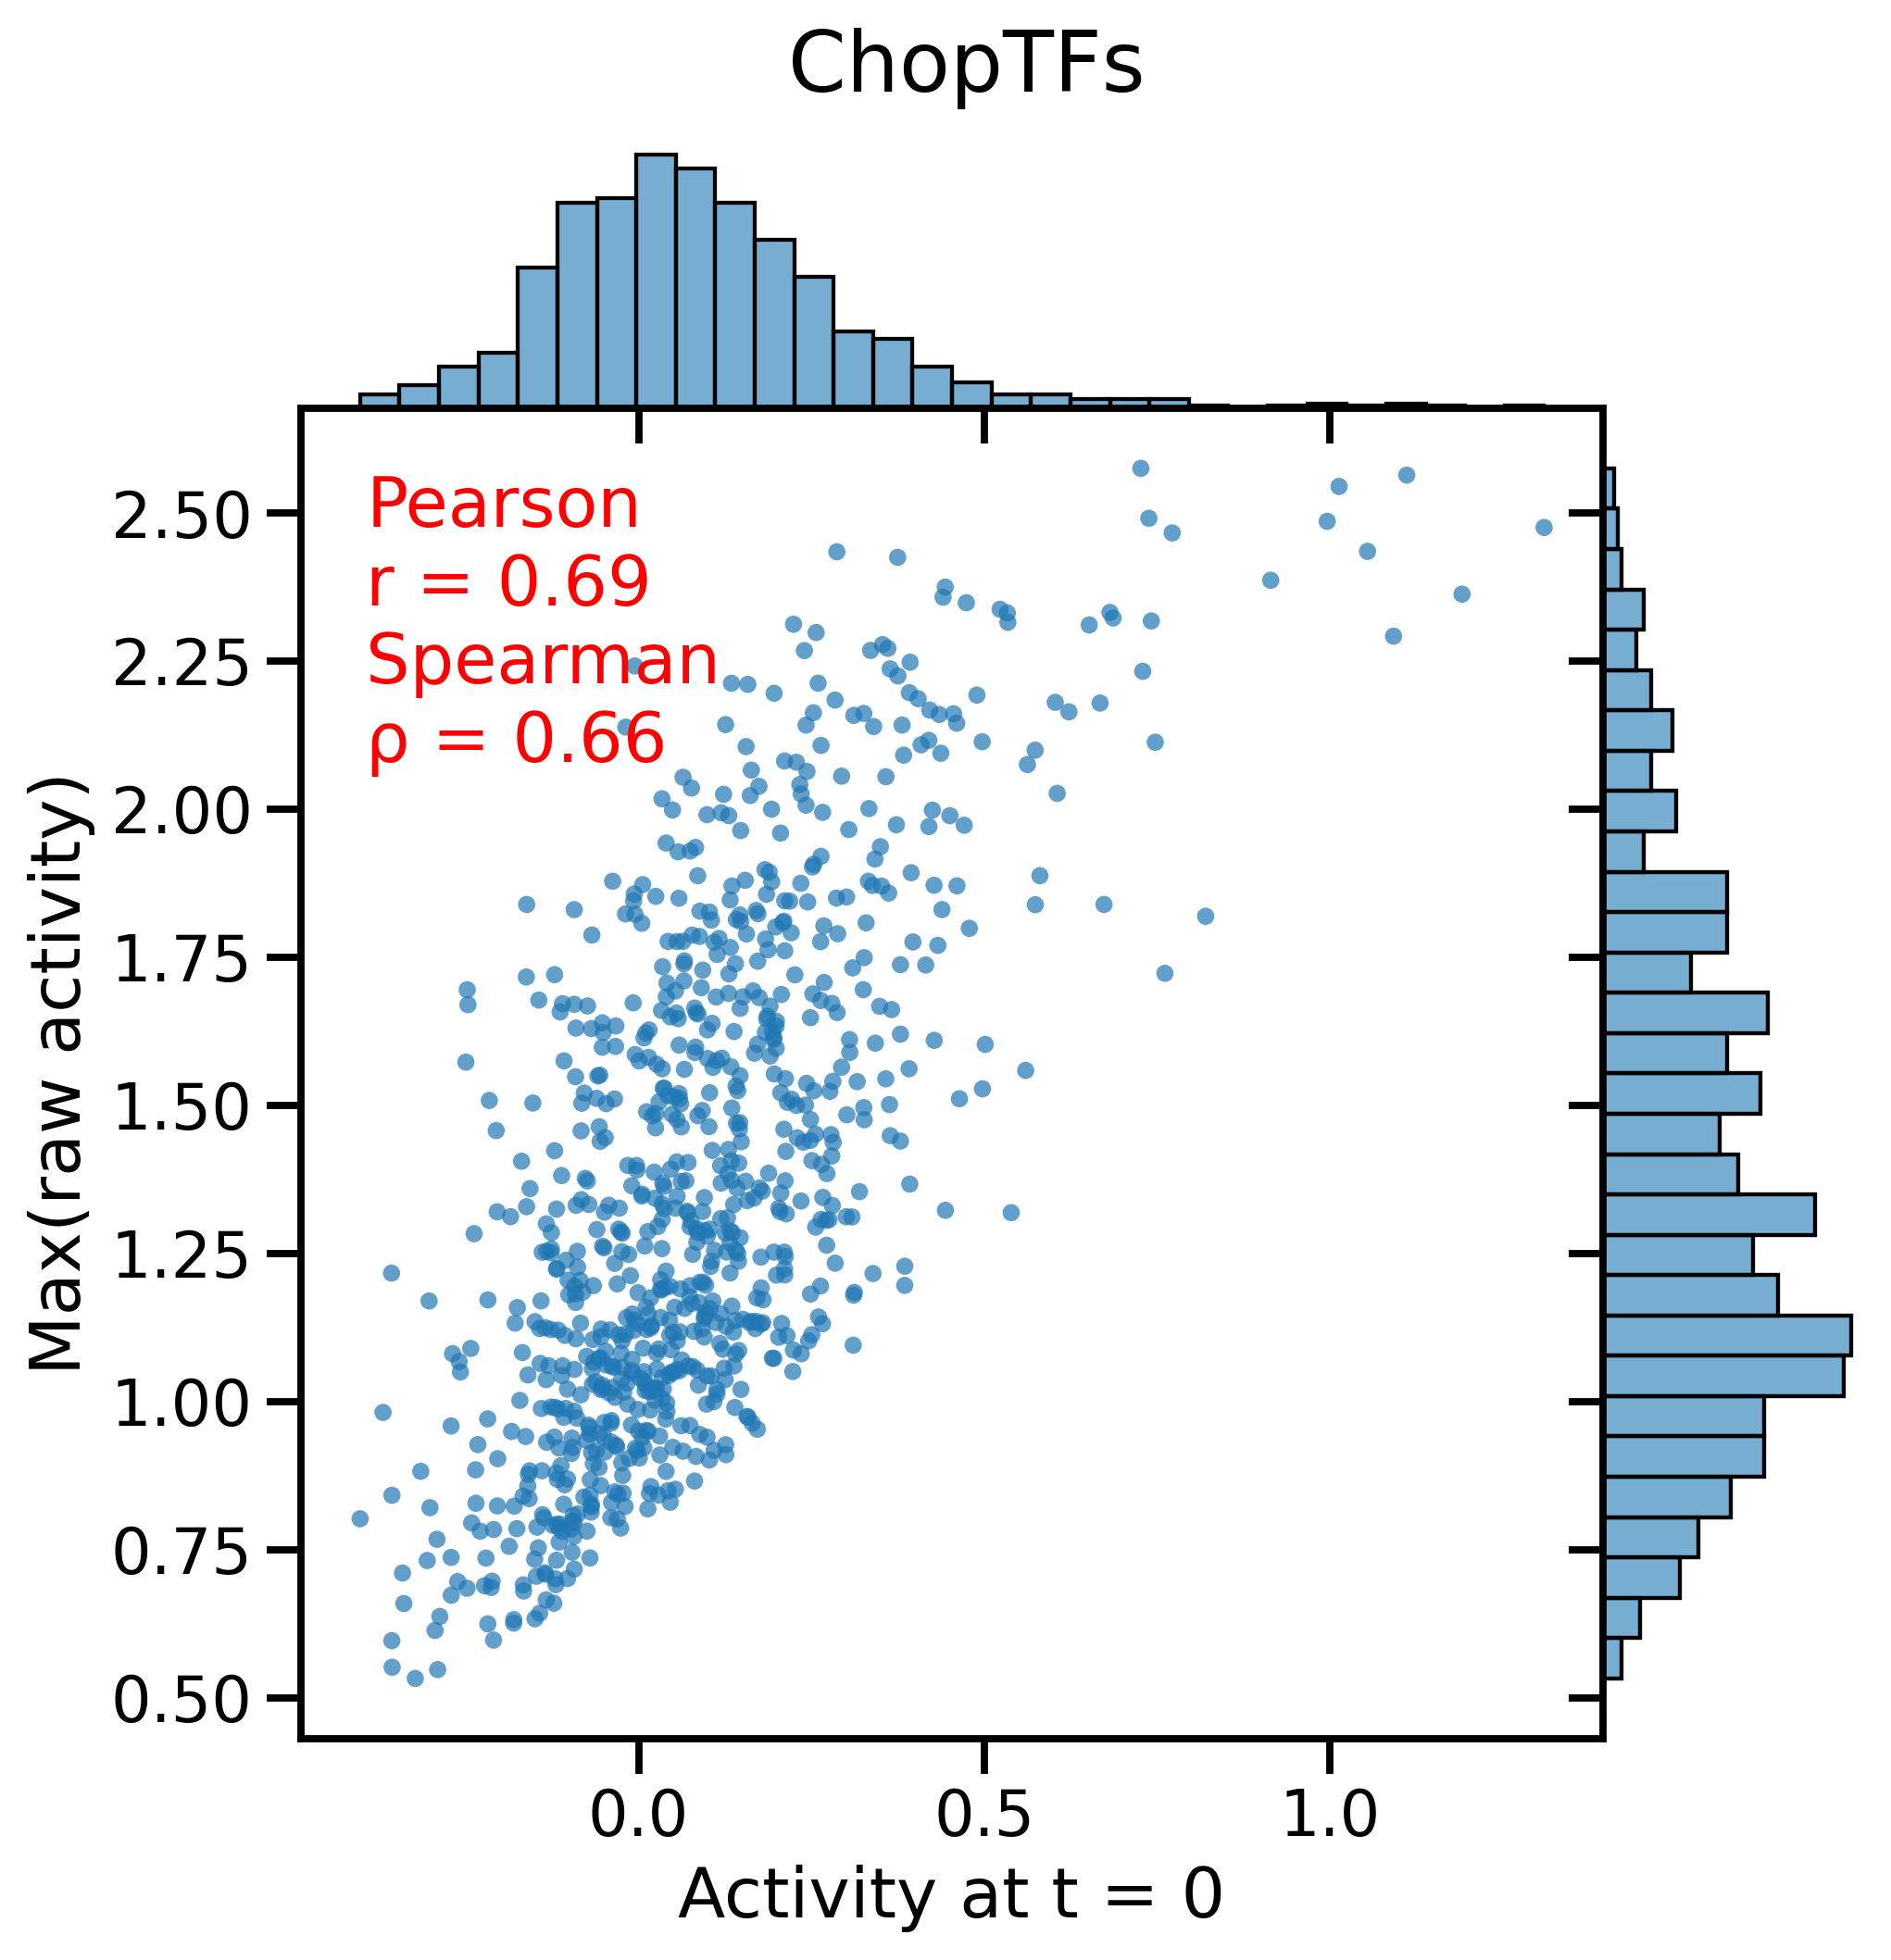

In [16]:
## Plotting
x = max_activities["activity_t0"]
y = max_activities["activity"]

# correlations
pearson_r = np.corrcoef(x, y)[0, 1]
spearman_r, spearman_p = spearmanr(x, y)

print(f"Pearson r = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.2e}")

sns.set_context('talk')

# joint plot with marginal histograms
g = sns.JointGrid(data=max_activities, x="activity_t0", y="activity", height=7, space=0)

# main scatter
g.plot_joint(
    sns.scatterplot,
    alpha=0.7,
    edgecolor='none',
    s=20
)

# marginal histograms
g.plot_marginals(
    sns.histplot,
    bins=30,
    alpha=0.6
)

# labels
g.set_axis_labels("Activity at t = 0", "Max(raw activity)")

# annotation
g.ax_joint.text(
    0.05, 0.95,
    f"Pearson\nr = {pearson_r:.2f}\nSpearman\nρ = {spearman_r:.2f}",
    transform=g.ax_joint.transAxes,
    ha='left',
    va='top',
    color = 'red'
)

g.fig.set_dpi(300)
g.fig.suptitle("ChopTFs", y=1.02)

plt.show()

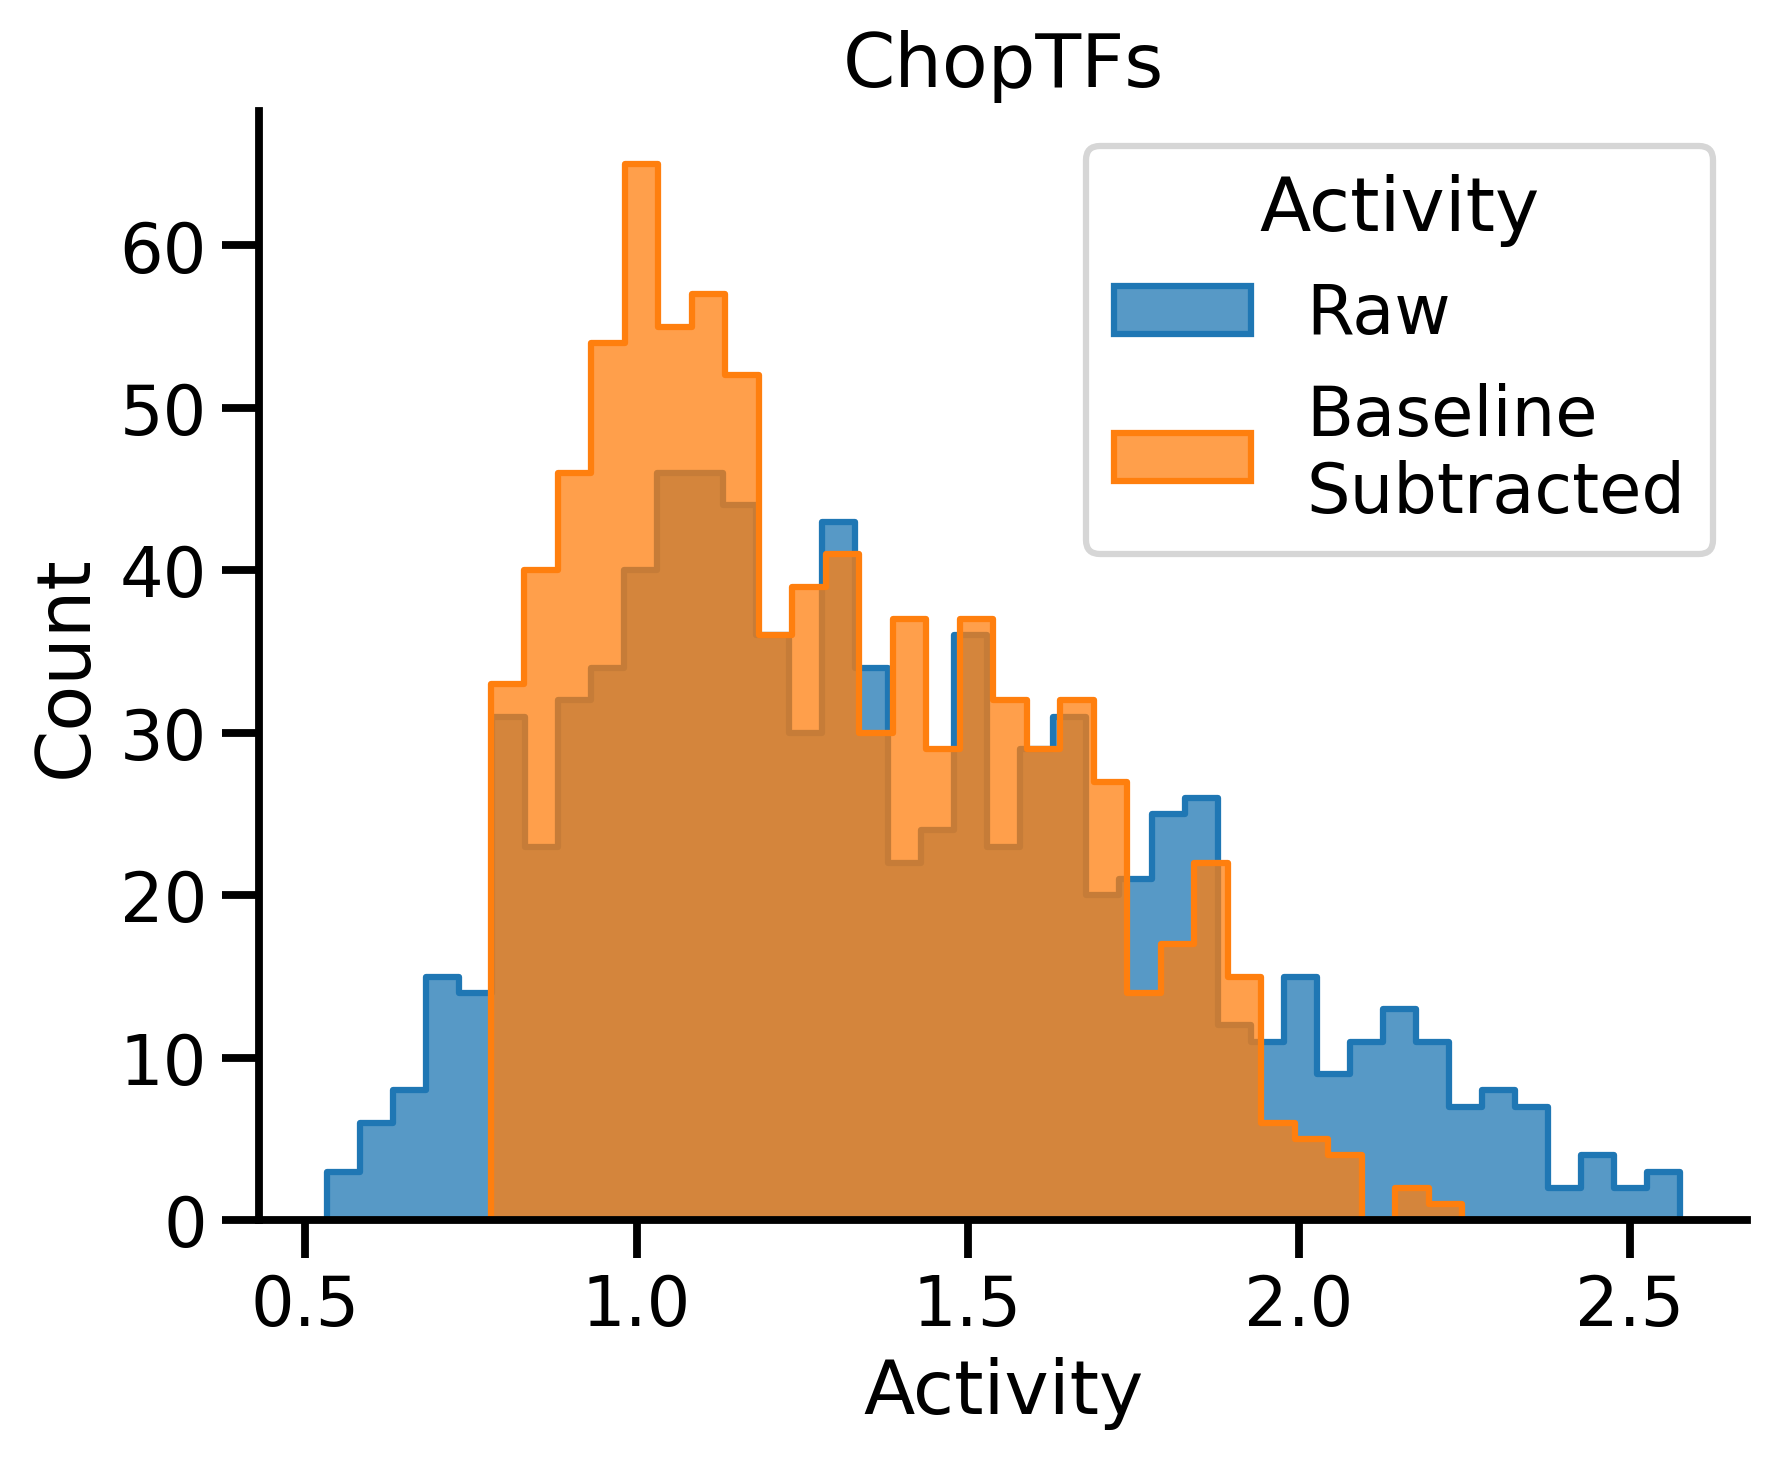

In [17]:
sns.set_context('talk')
plt.figure(dpi = 300)
plt.title("ChopTFs")
sns.histplot(data = max_activities, x = "activity", binwidth = 0.05, element ='step', label = "Raw")
sns.histplot(data = max_activities, x = "activity_norm", binwidth = 0.05, element ='step', label = "Baseline\nSubtracted")
plt.legend(title = "Activity")
plt.xlabel("Activity")
sns.despine()
plt.show()


Pearson r = 0.871
Spearman r = 0.886, p = 6.59e-288


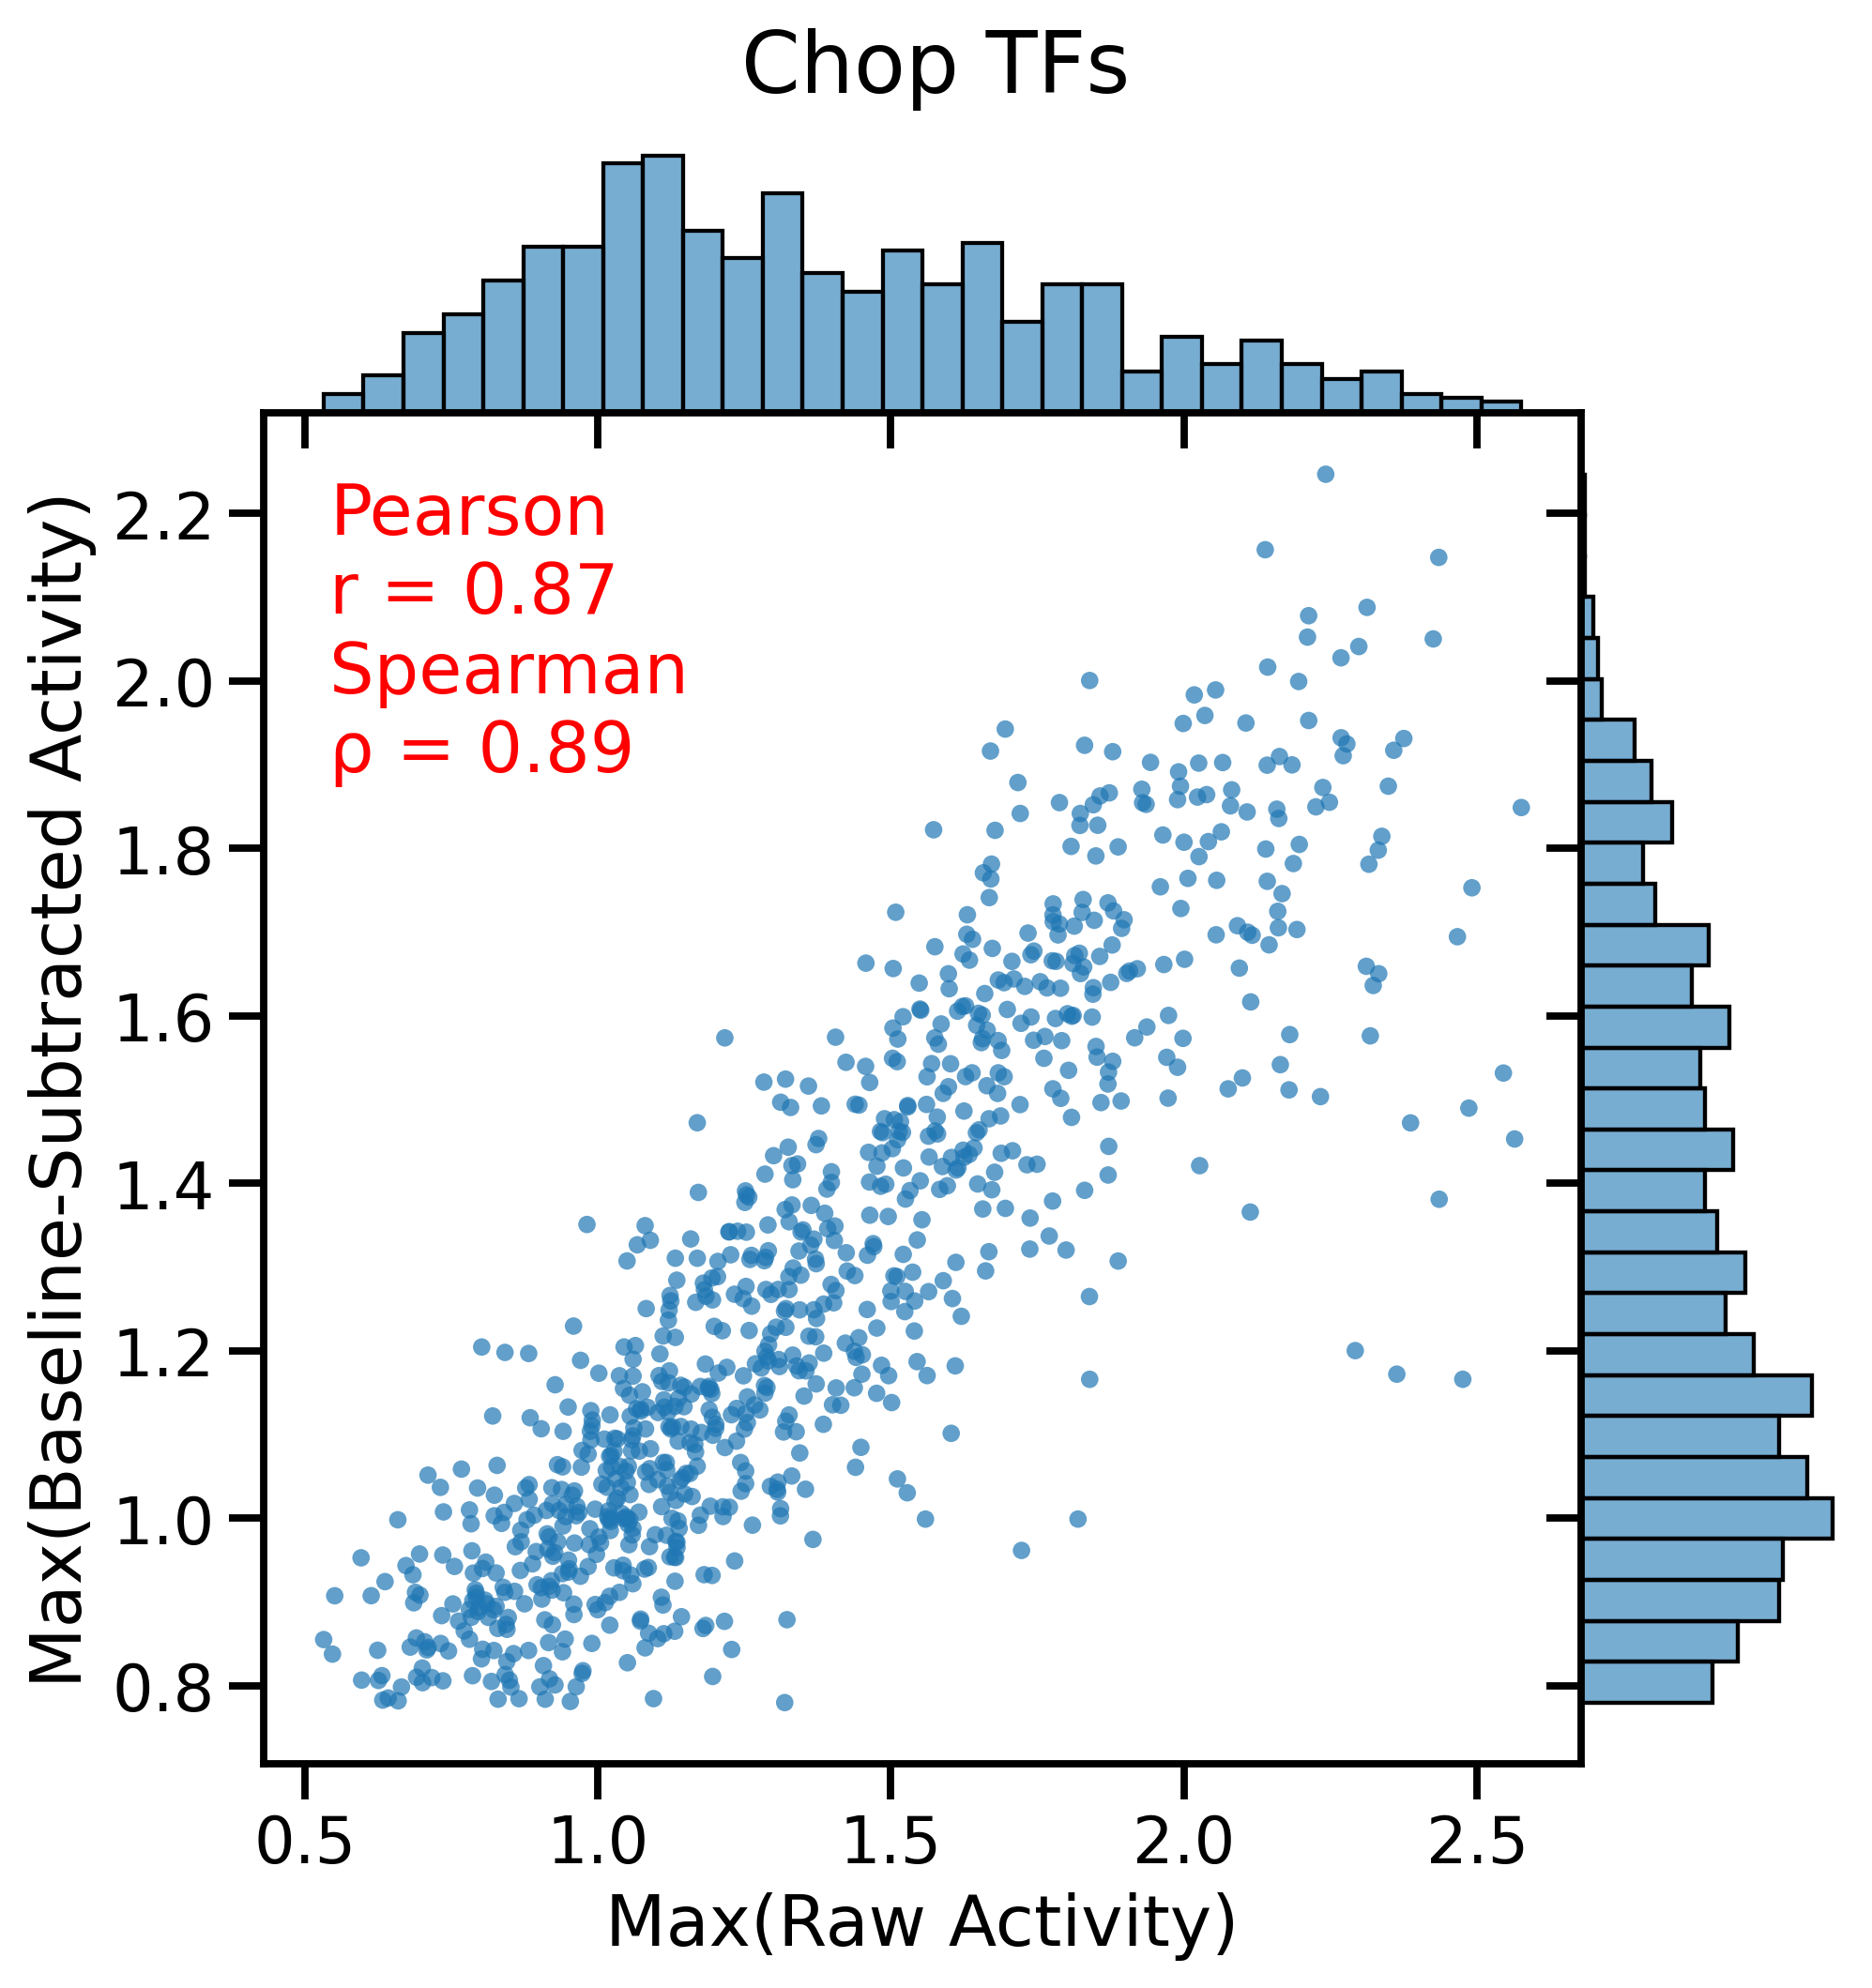

In [18]:
## Plotting

x = max_activities["activity"]
y = max_activities["activity_norm"]

# correlations
pearson_r = np.corrcoef(x, y)[0, 1]
spearman_r, spearman_p = spearmanr(x, y)

print(f"Pearson r = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.2e}")

sns.set_context("talk")

# joint plot
g = sns.JointGrid(data=max_activities, x="activity", y="activity_norm", height=7, space=0)

# main scatter
g.plot_joint(
    sns.scatterplot,
    alpha=0.7,
    edgecolor="none",
    s=20
)

# marginals
g.plot_marginals(
    sns.histplot,
    bins=30,
    alpha=0.6
)

# identity line (perfect agreement)
max_val = max(x.max(), y.max())
#g.ax_joint.plot([0, max_val], [0, max_val], "--", color="gray", linewidth=1)

# axis labels
g.set_axis_labels("Max(Raw Activity)", "Max(Baseline-Subtracted Activity)")

# annotation
g.ax_joint.text(
    0.05, 0.95,
    f"Pearson\nr = {pearson_r:.2f}\nSpearman\nρ = {spearman_r:.2f}",
    transform=g.ax_joint.transAxes,
    ha="left",
    va="top",
    color="red"
)

g.fig.set_dpi(300)
g.fig.suptitle("Chop TFs", y=1.02)

plt.show()